In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv("housing.csv")
df['income_cat'] = pd.cut(df['median_income'], bins = [0., 1.5, 3.0, 4.5, 6., np.inf], labels = [1, 2, 3, 4, 5])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  object  
 10  income_cat          20640 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.6+ MB


In [45]:
def suffle_and_split(data, test_ratio):
    np.random.seed(42)
    suffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = suffled_indices[:test_set_size]
    train_indices = suffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [46]:
data = [1, 2, 3, 4, 5]
train, test = suffle_and_split(df, 0.2)
print(f"train size: {len(train)}\n{train}\ntest size: {len(test)}\n{test}")

train size: 16512
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14196    -117.03     32.71                33.0       3126.0           627.0   
8267     -118.16     33.77                49.0       3382.0           787.0   
17445    -120.48     34.66                 4.0       1897.0           331.0   
14265    -117.11     32.69                36.0       1421.0           367.0   
2271     -119.80     36.78                43.0       2382.0           431.0   
...          ...       ...                 ...          ...             ...   
11284    -117.96     33.78                35.0       1330.0           201.0   
11964    -117.43     34.02                33.0       3084.0           570.0   
5390     -118.38     34.03                36.0       2101.0           569.0   
860      -121.96     37.58                15.0       3575.0           597.0   
15795    -122.42     37.77                52.0       4226.0          1315.0   

       population  households  me

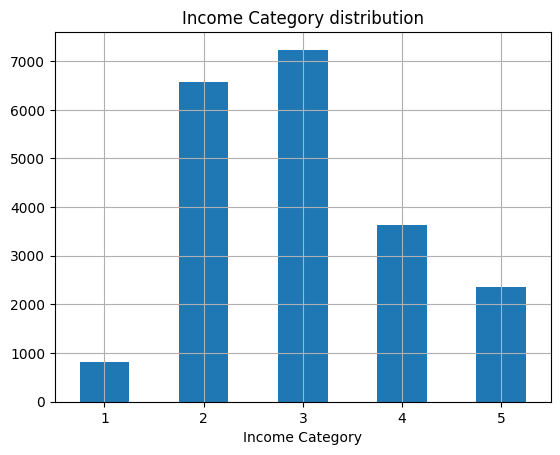

In [47]:
df['income_cat'].value_counts().sort_index().plot.bar(rot = 0, grid = True)
plt.title("Income Category distribution")
plt.xlabel("Income Category")
plt.show()

In [48]:
from sklearn.model_selection import StratifiedShuffleSplit

In [49]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    start_train_set = df.loc[train_index]
    start_test_set = df.loc[test_index]

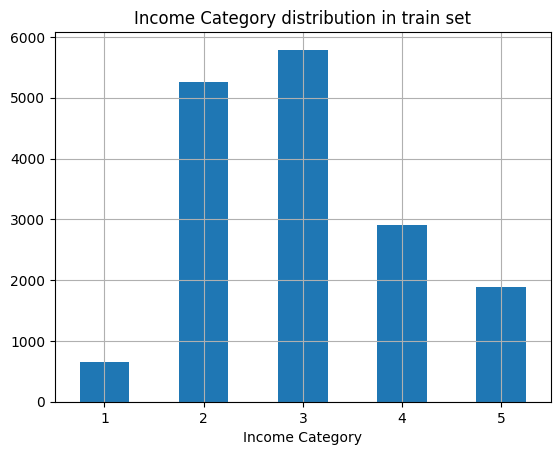

In [50]:
# start_train_set.info()
start_train_set["income_cat"].value_counts().sort_index().plot.bar(rot = 0, grid = True)
plt.title("Income Category distribution in train set")
plt.xlabel("Income Category")
plt.show()

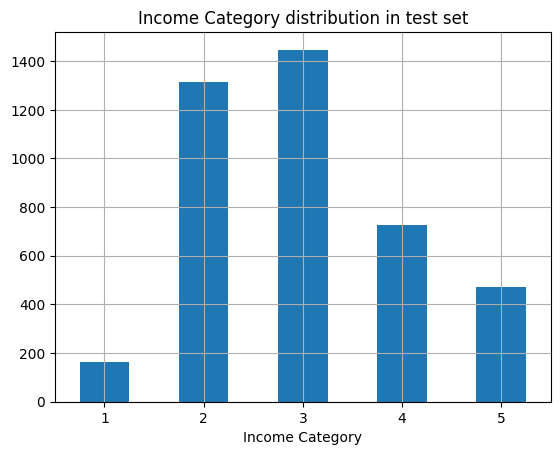

In [51]:
# start_test_set.info()
start_test_set["income_cat"].value_counts().sort_index().plot.bar(rot = 0, grid = True)
plt.title("Income Category distribution in test set")
plt.xlabel("Income Category")
plt.show()